In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import itertools
import warnings
import joblib

In [5]:
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('apartments_for_rent_classified.csv', sep=';', encoding='latin-1', low_memory=False)

In [7]:
df.head().iloc[:, :11]

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,NaN
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,NaN
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,NaN
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,NaN
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,NaN


In [8]:
df.head().iloc[:, 12:]

,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [9]:
df.isna().sum()

id                  0
category            0
title               0
body                0
amenities        3549
bathrooms          34
bedrooms            7
currency            0
fee                 0
has_photo           0
pets_allowed     4163
price               0
price_display       0
price_type          0
square_feet         0
address          3327
cityname           77
state              77
latitude           10
longitude          10
source              0
time                0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

id                0.00
category          0.00
title             0.00
body              0.00
amenities        35.49
bathrooms         0.34
bedrooms          0.07
currency          0.00
fee               0.00
has_photo         0.00
pets_allowed     41.63
price             0.00
price_display     0.00
price_type        0.00
square_feet       0.00
address          33.27
cityname          0.77
state             0.77
latitude          0.10
longitude         0.10
source            0.00
time              0.00
dtype: float64

In [11]:
cols_to_drop = ['id', 'title', 'body', 'amenities', 'price_display', 'address', 'source', 'time', 'currency', 'fee', 'has_photo', 'price_type', 'cityname']
df = df.drop(columns=cols_to_drop, errors='ignore')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   category      10000 non-null  object 
 1   bathrooms     9966 non-null   float64
 2   bedrooms      9993 non-null   float64
 3   pets_allowed  5837 non-null   object 
 4   price         10000 non-null  int64  
 5   square_feet   10000 non-null  int64  
 6   state         9923 non-null   object 
 7   latitude      9990 non-null   float64
 8   longitude     9990 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 703.3+ KB


In [13]:
numerical_cols = ['bathrooms', 'bedrooms', 'price', 'square_feet',  'latitude', 'longitude']

In [14]:
categorical_cols = ['pets_allowed', 'state', 'category']

In [15]:
(df.isnull().sum()/len(df))*100

category         0.00
bathrooms        0.34
bedrooms         0.07
pets_allowed    41.63
price            0.00
square_feet      0.00
state            0.77
latitude         0.10
longitude        0.10
dtype: float64

In [16]:
df['pets_allowed'] = df['pets_allowed'].fillna(df['pets_allowed'].mode()[0])

In [17]:
df.dropna(inplace = True)

In [18]:
(df.isnull().sum()/len(df))*100

category        0.0
bathrooms       0.0
bedrooms        0.0
pets_allowed    0.0
price           0.0
square_feet     0.0
state           0.0
latitude        0.0
longitude       0.0
dtype: float64

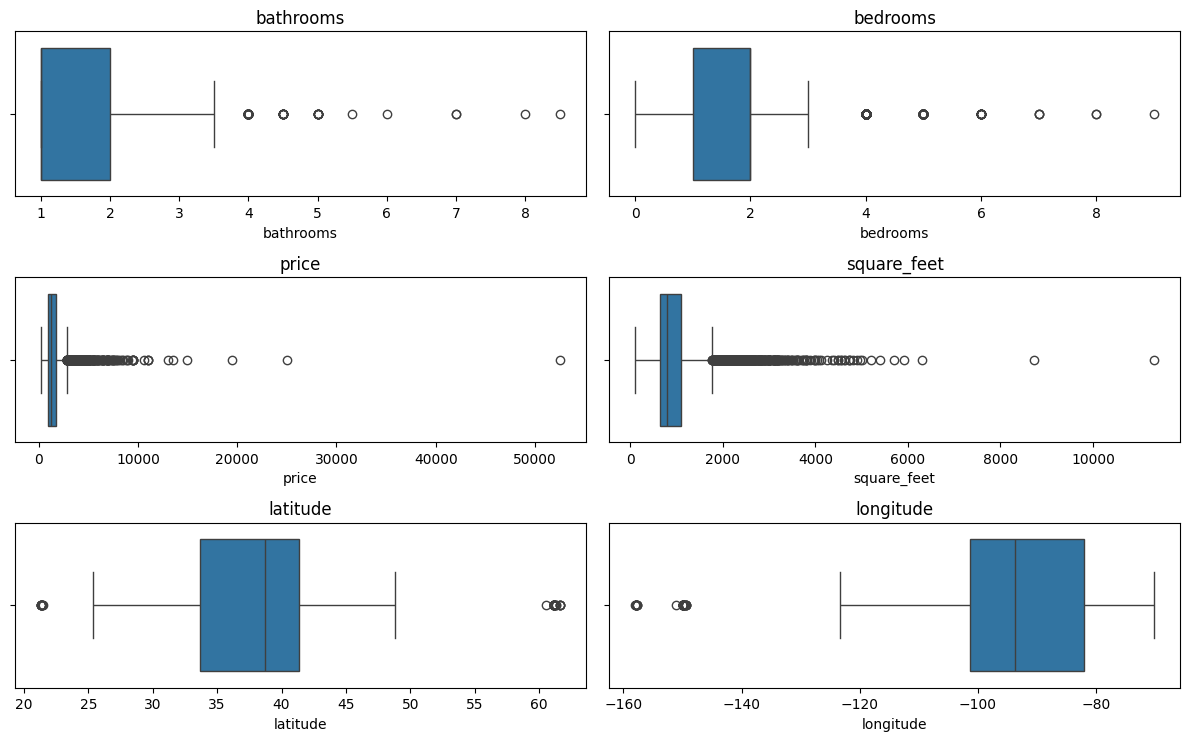

In [19]:
plt.figure(figsize = (12,12))
for i, col in enumerate(numerical_cols):
    plt.subplot(5,2,i+1)
    sns.boxplot(data = df, x = col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [20]:
df_clean = df.copy()
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)

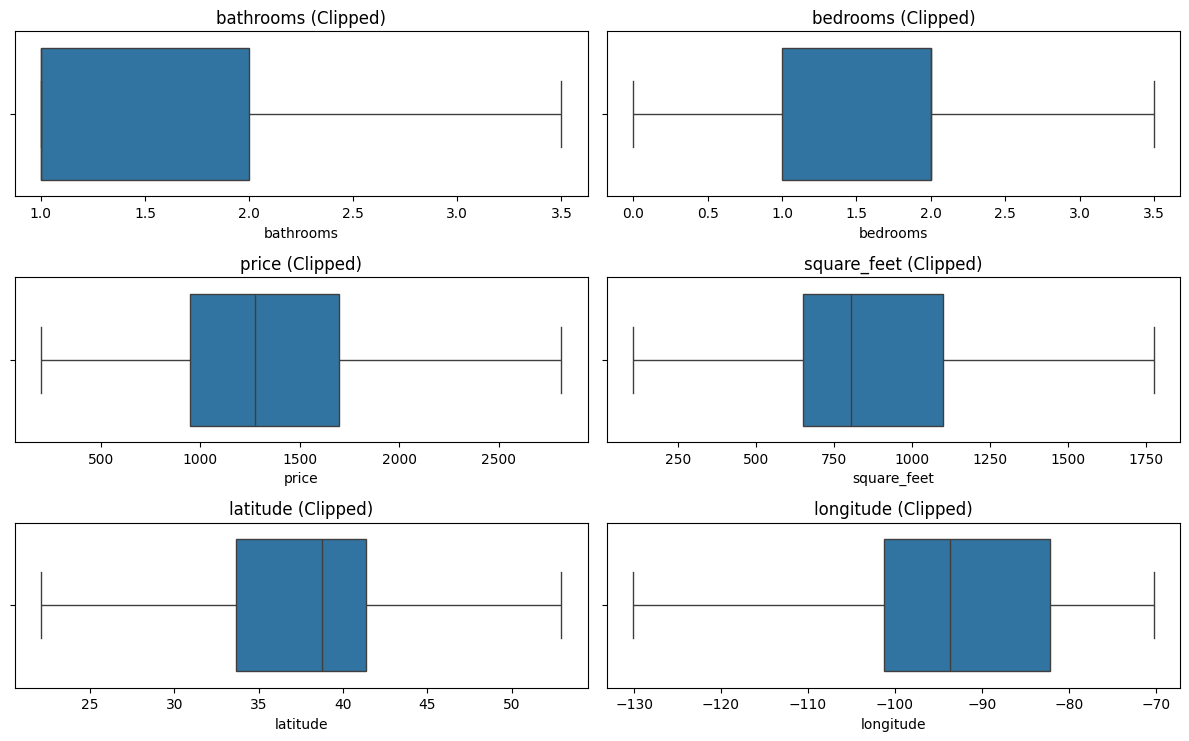

In [21]:
plt.figure(figsize=(12,12))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 2, i+1)
    sns.boxplot(data=df_clean, x=col)
    plt.title(f"{col} (Clipped)")
plt.tight_layout()
plt.show()

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

In [23]:
X_processed = preprocessor.fit_transform(df_clean)

In [24]:
np.random.seed(42)
if X_processed.shape[0] > 3000:
    indices = np.random.choice(X_processed.shape[0], 3000, replace=False)
    X_train = X_processed[indices]
else:
    X_train = X_processed

In [25]:
best_models = {}
best_k_kmeans = -1
best_score_kmeans = -1

In [26]:
best_k_kmeans = -1
best_score_kmeans = -1
for k in range(2, 6):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_train)
    score = silhouette_score(X_train, labels)
    if score > best_score_kmeans:
        best_score_kmeans = score
        best_k_kmeans = k
best_models['KMeans'] = {'k': best_k_kmeans, 'score': best_score_kmeans}

In [27]:
best_k_agg = -1
best_score_agg = -1
for k in range(2, 6):
    labels = AgglomerativeClustering(n_clusters=k).fit_predict(X_train)
    score = silhouette_score(X_train, labels)
    if score > best_score_agg:
        best_score_agg = score
        best_k_agg = k
best_models['Agglomerative'] = {'k': best_k_agg, 'score': best_score_agg}

In [28]:
best_eps = -1
best_min = -1
best_score_dbscan = -1
for eps, min_samples in itertools.product([1.0, 1.5, 2.0], [5, 10]):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_train)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        score = silhouette_score(X_train, labels)
        if score > best_score_dbscan:
            best_score_dbscan = score
            best_eps = eps
            best_min = min_samples

In [29]:
if best_score_dbscan != -1:
    best_models['DBSCAN'] = {'eps': best_eps, 'min_samples': best_min, 'score': best_score_dbscan}
else:
    best_models['DBSCAN'] = {'eps': None, 'min_samples': None, 'score': -1}

In [30]:
best_overall_name = max(best_models, key=lambda k: best_models[k]['score'])

In [31]:
best_overall_name

'KMeans'

In [32]:
best_models

{'KMeans': {'k': 2, 'score': 0.29080385003324094},
 'Agglomerative': {'k': 2, 'score': 0.28734475750588295},
 'DBSCAN': {'eps': 1.0, 'min_samples': 5, 'score': 0.19826448201804933}}

In [33]:
if best_overall_name == 'KMeans':
    final_model = KMeans(n_clusters=best_models['KMeans']['k'], random_state=42, n_init=10)
elif best_overall_name == 'Agglomerative':
    final_model = AgglomerativeClustering(n_clusters=best_models['Agglomerative']['k'])
else:
    final_model = DBSCAN(eps=best_models['DBSCAN']['eps'], min_samples=best_models['DBSCAN']['min_samples'])

In [34]:
final_model.fit(X_processed)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [35]:
joblib.dump(final_model, 'best_clustering_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']